In [48]:
import numpy as np
import pandas as pd

dataset_name = "heart"
explainer_name = "sage"
strategy = "permutation"
size = 64

In [49]:
data = pd.read_csv(f"results/{dataset_name}/results_{explainer_name}_{strategy}_kernels_comparison.csv")

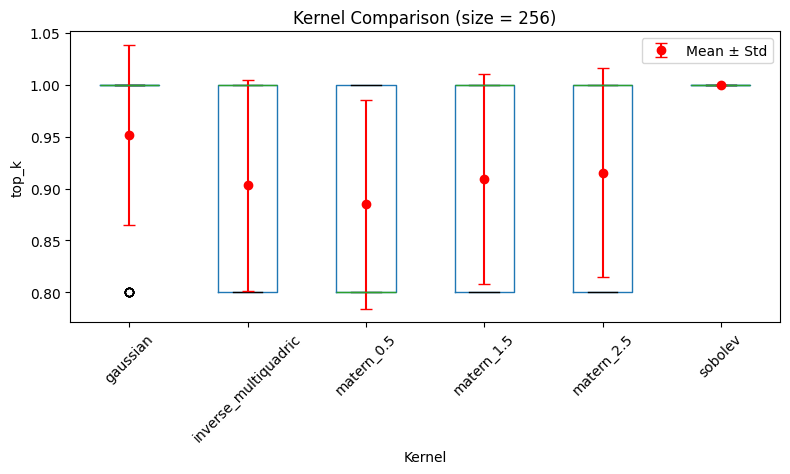

In [ ]:
import matplotlib.pyplot as plt

# Filter rows where size = 256
filtered = data[data['size'] == size]

# Create the box plot
fig, ax = plt.subplots(figsize=(8, 5))

# Box plot for top_k grouped by kernel
filtered.boxplot(column='top_k', by='kernel', ax=ax, grid=False)

# Overlay mean and standard deviation lines
means = filtered.groupby('kernel')['top_k'].mean()
stds = filtered.groupby('kernel')['top_k'].std()

ax.errorbar(
    x=range(1, len(means) + 1),
    y=means,
    yerr=stds,
    fmt='o',
    color='red',
    capsize=4,
    label='Mean ± Std'
)

plt.title('Kernel Comparison (size = 256)')
plt.suptitle('')  # Remove default subtitle
plt.xlabel('Kernel')
plt.ylabel('top_k')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()